In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# make charts look professional
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [3]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

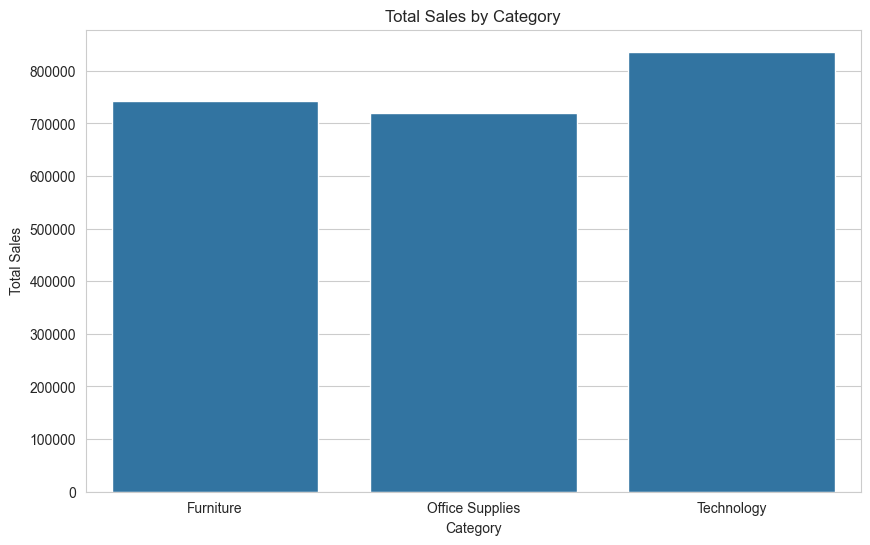

In [13]:
sales_category = df.groupby("Category")["Sales"].sum().reset_index()

sns.barplot(data=sales_category, x="Category", y="Sales")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.savefig("images/sales_by_category.png", bbox_inches="tight")
plt.show()

Insight:
Technology generates the highest sales, followed by Furniture and Office Supplies. This indicates strong demand for tech products.

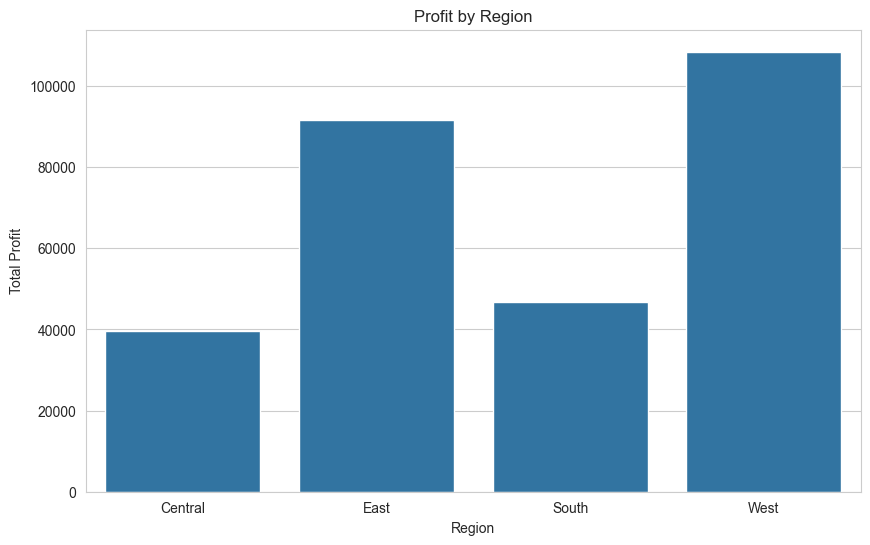

In [14]:
profit_region = df.groupby("Region")["Profit"].sum().reset_index()

sns.barplot(data=profit_region, x="Region", y="Profit")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.savefig("images/profit_by_region.png", bbox_inches="tight")
plt.show()

Profit varies by region, with the West and East regions contributing the highest overall profit, indicating strong business performance in these areas.

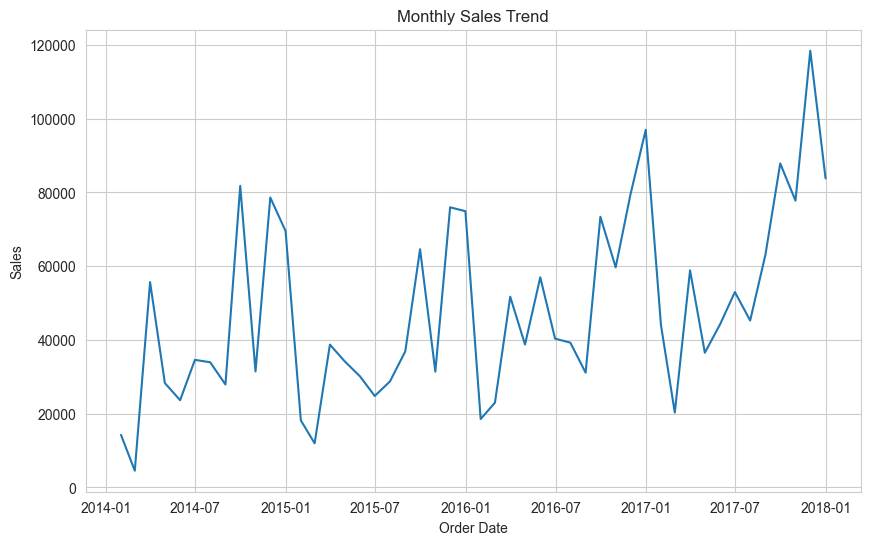

In [15]:
monthly_sales = df.resample('ME', on='Order Date')["Sales"].sum().reset_index()

sns.lineplot(data=monthly_sales, x="Order Date", y="Sales")
plt.title("Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.savefig("images/monthly_sales_trend.png", bbox_inches="tight")
plt.show()

Sales show an overall upward trend over time with periodic fluctuations, indicating business growth with seasonal demand patterns.

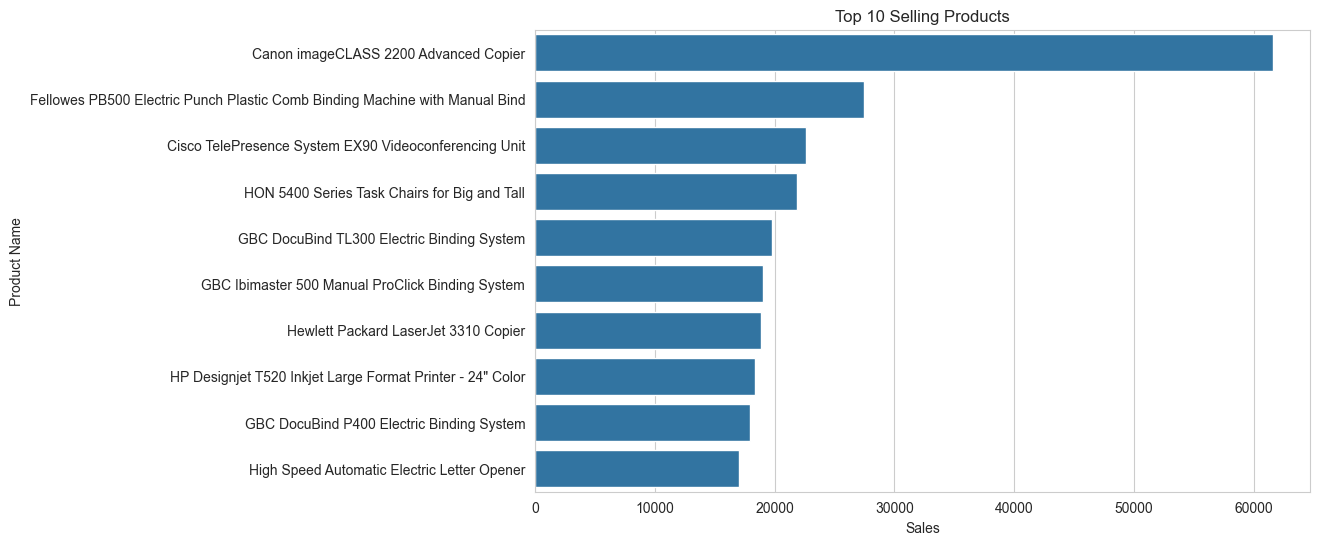

In [16]:
top_products = df.groupby("Product Name")["Sales"].sum().nlargest(10).reset_index()

sns.barplot(data=top_products, y="Product Name", x="Sales")
plt.title("Top 10 Selling Products")
plt.xlabel("Sales")
plt.ylabel("Product Name")

plt.savefig("images/top_products.png", bbox_inches="tight")
plt.show()

A small number of products contribute significantly to total sales, highlighting the importance of top-performing items in driving revenue.

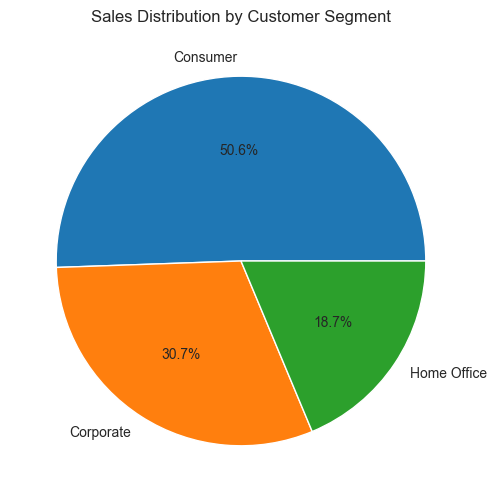

In [17]:
segment_sales = df.groupby("Segment")["Sales"].sum()

plt.pie(segment_sales, labels=segment_sales.index, autopct='%1.1f%%')
plt.title("Sales Distribution by Customer Segment")

plt.savefig("images/sales_by_segment.png", bbox_inches="tight")
plt.show()

The Consumer segment contributes the largest share of sales, making it the most valuable customer group for the business.

Final Key Insights

• Technology is the top-performing category in sales.
• West and East regions generate the highest profit.
• Sales show steady growth over time with seasonal patterns.
• A few top products drive a large portion of revenue.
• The Consumer segment is the biggest contributor to overall sales.